# Job Market Intelligence v4 — Exploratory Data Analysis
Comprehensive EDA for the job market dataset.

# 1. Load libraries

In [32]:
import sys
from pathlib import Path

In [33]:
# Adjust path to find src/ from the notebooks/ folder
sys.path.insert(0, str(Path.cwd().parent))

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_and_prepare
from src.utils import logger

In [35]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
OUTPUT_DIR = Path.cwd().parent / "visuals"
OUTPUT_DIR.mkdir(exist_ok=True)

In [36]:
# Load Data
df_all, df_dsml = load_and_prepare()
print(" Data loaded successfully!")

2026-08-05 22:13:19,789 [INFO] job_market_v4: All jobs cleaned: 555 rows
2026-08-05 22:13:19,794 [INFO] job_market_v4: DS/ML/DL subset: 411 rows in 5 fields
2026-08-05 22:13:19,798 [INFO] job_market_v4: Saved all_jobs.csv (555 rows) + ds_ml_dl_jobs.csv (411 rows)


 Data loaded successfully!


## 2. All Jobs Overview

In [37]:
print(f"Shape: {df_all.shape}")
print(f"\nColumns: {df_all.columns.tolist()}")
print(f"\nDtypes:\n{df_all.dtypes}")

Shape: (555, 11)

Columns: ['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

Dtypes:
work_year             int64
experience_level        str
employment_type         str
job_title               str
salary                int64
salary_currency         str
salary_in_usd         int64
employee_residence      str
remote_ratio          int64
company_location        str
company_size            str
dtype: object


In [38]:
print(f"\nFirst 5 rows:\n{df_all.head().to_string()}")
print(f"\nDescribe:\n{df_all.describe().to_string()}")


First 5 rows:
   work_year experience_level employment_type                   job_title  salary salary_currency  salary_in_usd employee_residence  remote_ratio company_location company_size
0       2020        Mid Level              FT              Data Scientist   70000             EUR          79833            Germany             0          Germany            L
1       2020     Senior Level              FT  Machine Learning Scientist  260000             USD         260000              Japan             0            Japan            S
2       2020     Senior Level              FT           Big Data Engineer   85000             GBP         109024     United Kingdom            50   United Kingdom            M
3       2020        Mid Level              FT        Product Data Analyst   20000             USD          20000           Honduras             0         Honduras            S
4       2020     Senior Level              FT   Machine Learning Engineer  150000             USD        

## 3. Missing Values

In [39]:
missing = df_all.isnull().sum()
missing = missing[missing > 0]
if not missing.empty:
    print(missing.to_string())
else:
    print(" No missing values!")

 No missing values!


## 4. Categorical Distributions

In [40]:
categorical_cols = ["experience_level", "employment_type", "company_size", "remote_ratio", "company_location"]
for col in categorical_cols:
    if col in df_all.columns:
        print(f"\n--- {col} ---")
        print(df_all[col].value_counts().head(10).to_string())


--- experience_level ---
experience_level
Senior Level       240
Mid Level          205
Entry Level         88
Executive Level     22

--- employment_type ---
employment_type
FT    537
PT     10
CT      4
FL      4

--- company_size ---
company_size
M    288
L    186
S     81

--- remote_ratio ---
remote_ratio
100    338
0      120
50      97

--- company_location ---
company_location
United States     308
United Kingdom     46
Canada             28
Germany            27
India              24
France             15
Spain              14
Greece             10
Japan               6
Netherlands         4


## 5. Salary by Experience Level

In [41]:
salary_exp = df_all.groupby("experience_level")["salary_in_usd"].agg(["mean", "median", "min", "max", "count"]).round(0)
print(salary_exp.to_string())

                      mean    median    min     max  count
experience_level                                          
Entry Level        61643.0   56500.0   4000  250000     88
Executive Level   159963.0  151834.0  69741  250000     22
Mid Level          82624.0   75774.0   2859  270000    205
Senior Level      135117.0  135000.0  18907  276000    240


## 6. Salary by Company Size

In [42]:
salary_size = df_all.groupby("company_size")["salary_in_usd"].agg(["mean", "median", "count"]).round(0)
print(salary_size.to_string())

                  mean    median  count
company_size                           
L             106561.0   95389.0    186
M             112917.0  109280.0    288
S              73698.0   65000.0     81


## 7. DS / ML / DL Subset

In [43]:
print(f"Shape: {df_dsml.shape}")

Shape: (411, 12)


In [44]:
print(f"\nDS/ML Fields:\n{df_dsml['ds_ml_field'].value_counts().to_string()}")


DS/ML Fields:
ds_ml_field
Data Science        175
Data Engineering    145
Machine Learning     65
Research             15
AI Specialized       11


In [45]:
print(f"\nSalary by DS/ML Field:")
dsml_salary = df_dsml.groupby("ds_ml_field")["salary_in_usd"].agg(["mean", "median", "count"]).round(0).sort_values("median", ascending=False)
print(dsml_salary.to_string())


Salary by DS/ML Field:
                      mean    median  count
ds_ml_field                                
Data Science      110297.0  105000.0    175
Data Engineering  108785.0  103160.0    145
Machine Learning  106279.0   87425.0     65
Research           86287.0   69999.0     15
AI Specialized     56810.0   37236.0     11


## 8. Top 20 Job Titles

In [46]:
top_titles = df_all["job_title"].value_counts().head(20)
print(top_titles.to_string())

job_title
Data Scientist                129
Data Engineer                 120
Data Analyst                   82
Machine Learning Engineer      39
Research Scientist             15
Data Science Manager           12
Data Architect                 11
Machine Learning Scientist      8
Big Data Engineer               8
Data Science Consultant         7
AI Scientist                    7
Data Analytics Manager          7
Lead Data Engineer              6
BI Data Analyst                 6
ML Engineer                     6
Computer Vision Engineer        6
Principal Data Scientist        6
Director of Data Science        6
Business Data Analyst           5
Data Engineering Manager        5


## 9. Salary Trends by Work Year

In [47]:
year_salary = df_all.groupby("work_year")["salary_in_usd"].agg(["mean", "median", "count"]).round(0)
print(year_salary.to_string())

               mean    median  count
work_year                           
2020        82776.0   72000.0     69
2021        92363.0   81000.0    211
2022       120399.0  118187.0    275


## 10. Visualizations

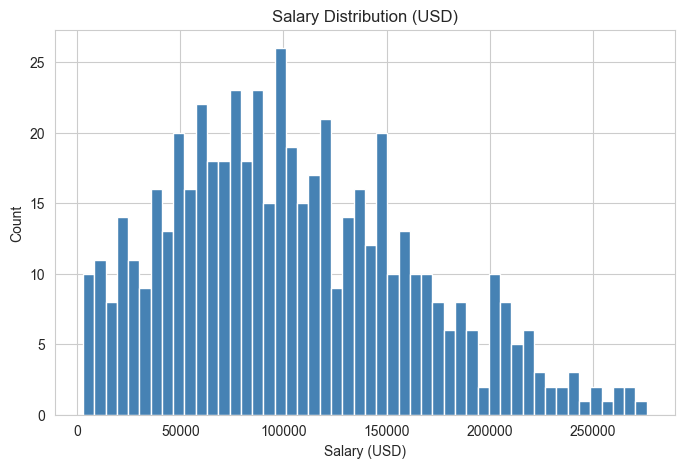

In [48]:
# Chart 1: Salary Distribution
fig, ax = plt.subplots(figsize=(8, 5))
df_all["salary_in_usd"].hist(bins=50, color="steelblue", edgecolor="white", ax=ax)
ax.set_title("Salary Distribution (USD)")
ax.set_xlabel("Salary (USD)")
ax.set_ylabel("Count")
fig.savefig(OUTPUT_DIR / "salary_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

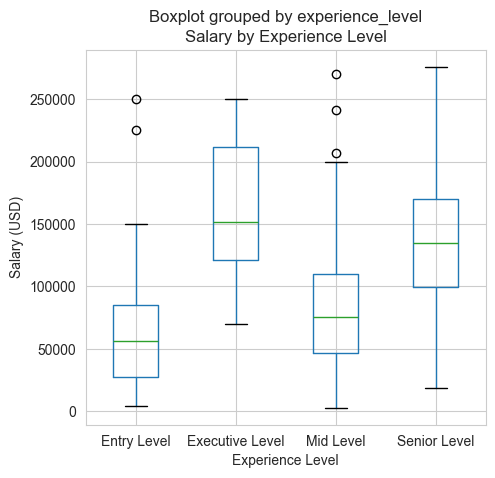

In [49]:
# Chart 2: Salary by Experience (Boxplot)
fig, ax = plt.subplots(figsize=(5, 5))
df_all.boxplot(column="salary_in_usd", by="experience_level", ax=ax)
ax.set_title("Salary by Experience Level")
ax.set_xlabel("Experience Level")
ax.set_ylabel("Salary (USD)")
fig.savefig(OUTPUT_DIR / "salary_by_experience_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

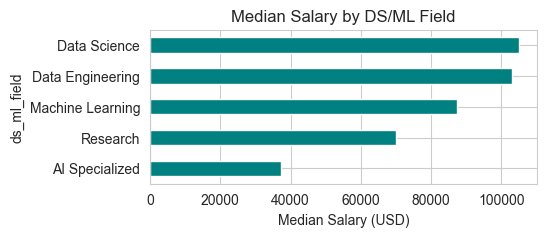

In [50]:
# Chart 3: Salary by DS/ML Field (Bar)
fig, ax = plt.subplots(figsize=(5, 2))
dsml_salary_plot = df_dsml.groupby("ds_ml_field")["salary_in_usd"].median().sort_values()
dsml_salary_plot.plot(kind="barh", color="teal", ax=ax)
ax.set_title("Median Salary by DS/ML Field")
ax.set_xlabel("Median Salary (USD)")
fig.savefig(OUTPUT_DIR / "salary_by_dsml_field.png", dpi=150, bbox_inches="tight")
plt.show()

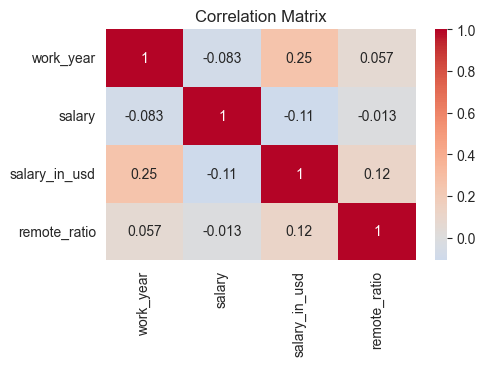

In [51]:
# Chart 4: Correlation Heatmap
numeric_cols = df_all.select_dtypes(include=[np.number]).columns
fig, ax = plt.subplots(figsize=(5, 3))
sns.heatmap(df_all[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix")
fig.savefig(OUTPUT_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Key Insights

In [52]:
print("=" * 70)
print("KEY INSIGHTS")
print("=" * 70)
print(f"• Total jobs analyzed: {len(df_all):,}")
print(f"• DS/ML/DL specific jobs: {len(df_dsml):,}")
print(f"• Median salary (all jobs): ${df_all['salary_in_usd'].median():,.0f}")
print(f"• Median salary (DS/ML/DL): ${df_dsml['salary_in_usd'].median():,.0f}")
print(f"• Most common experience: {df_all['experience_level'].mode().iloc[0]}")
print(f"• Year range: {df_all['work_year'].min()} - {df_all['work_year'].max()}")
print(f"• Countries represented: {df_all['company_location'].nunique()}")
print(f"• Unique job titles: {df_all['job_title'].nunique()}")
print(f"• Top DS/ML field: {df_dsml['ds_ml_field'].value_counts().index[0]}")
print("\n EDA complete! Charts saved to visuals/")

KEY INSIGHTS
• Total jobs analyzed: 555
• DS/ML/DL specific jobs: 411
• Median salary (all jobs): $100,000
• Median salary (DS/ML/DL): $100,000
• Most common experience: Senior Level
• Year range: 2020 - 2022
• Countries represented: 50
• Unique job titles: 49
• Top DS/ML field: Data Science

 EDA complete! Charts saved to visuals/


# Job Market Intelligence v4 — Exploratory Data Analysis
Comprehensive EDA for the job market dataset.

In [53]:
# Adjust path to find src/ from the notebooks/ folder
sys.path.insert(0, str(Path.cwd().parent))

In [54]:
# Config
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
OUTPUT_DIR = Path.cwd().parent / "visuals"
OUTPUT_DIR.mkdir(exist_ok=True)

In [55]:
# Load Data
df_all, df_dsml = load_and_prepare()
print(" Data loaded successfully!")

2026-08-05 22:13:20,419 [INFO] job_market_v4: All jobs cleaned: 555 rows
2026-08-05 22:13:20,423 [INFO] job_market_v4: DS/ML/DL subset: 411 rows in 5 fields
2026-08-05 22:13:20,428 [INFO] job_market_v4: Saved all_jobs.csv (555 rows) + ds_ml_dl_jobs.csv (411 rows)


 Data loaded successfully!


## 12. All Jobs Overview

In [56]:
print(f"Shape: {df_all.shape}")

Shape: (555, 11)


In [57]:
print(f"\nColumns: {df_all.columns.tolist()}")
print(f"\nDtypes:\n{df_all.dtypes}")
print(f"\nFirst 5 rows:\n{df_all.head().to_string()}")
print(f"\nDescribe:\n{df_all.describe().round(2).to_string()}")


Columns: ['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

Dtypes:
work_year             int64
experience_level        str
employment_type         str
job_title               str
salary                int64
salary_currency         str
salary_in_usd         int64
employee_residence      str
remote_ratio          int64
company_location        str
company_size            str
dtype: object

First 5 rows:
   work_year experience_level employment_type                   job_title  salary salary_currency  salary_in_usd employee_residence  remote_ratio company_location company_size
0       2020        Mid Level              FT              Data Scientist   70000             EUR          79833            Germany             0          Germany            L
1       2020     Senior Level              FT  Machine Learning Scientist  260000             USD         